# 14. 고윳값 분해와 SVD 응용

## PCA·LDA·이미지 압축으로 연결하기

- **배울 것**: 공분산 고유분해와 데이터 SVD의 관계, 분류에 유리한 방향, 저랭크 이미지 근사.
- 주가 수익률은 원본에 지정된 UCI 고정 데이터입니다. 여기서는 행렬 계산 예제로만 사용합니다.
- 이미지 압축은 직접 생성한 도형 이미지를 사용합니다. 원본 코드의 `strav` 변수명은 유지했지만 Picasso 이미지에 대한 수치 결과는 아닙니다.

## PCA: 데이터가 가장 많이 퍼진 방향

$$
C=\frac{X_c^TX_c}{N-1}=V\Lambda V^T,\quad
X_c=U\Sigma V^T,\quad \lambda_i=\frac{\sigma_i^2}{N-1}
$$

- 각 열의 평균을 뺀 다음 공분산을 구합니다. 큰 고윳값에 대응하는 방향부터 선택합니다.
- **방향**은 V의 열, **점수**는 $Z=X_cV_k$, **설명분산 비율**은 $\lambda_i/\sum_j\lambda_j$입니다. 셋을 혼동하지 않습니다.
- 변수 단위가 다르면 표준화 여부에 따라 주성분이 달라집니다. 원본은 공분산 PCA입니다.
- PCA는 분산을 보존합니다. 가장 분산이 큰 방향이 분류에 가장 유용하다는 보장은 없습니다.

## LDA: 집단 사이 거리를 집단 내부 퍼짐과 비교

$$
J(\mathbf w)=\frac{\mathbf w^TS_B\mathbf w}{\mathbf w^TS_W\mathbf w},\qquad
S_B\mathbf w=\lambda S_W\mathbf w
$$

- 같은 집단의 점들은 모으고 다른 집단의 평균은 떨어뜨리는 방향을 찾습니다. 라벨을 사용하는 지도학습입니다.
- 원본처럼 두 집단 크기가 같은 경우 집단별 공분산 평균으로 $S_W$를 구성할 수 있습니다.
- 고유벡터 부호는 임의이므로 `점수>0`을 무조건 클래스 1로 정하면 뒤집힐 수 있습니다. 학습 집단 평균으로 방향과 경계를 정합니다.
- shrinkage는 불안정한 공분산을 더 단순한 행렬 쪽으로 조정합니다. 아래에서는 같은 분할을 여러 강도에 적용해 평균 검증 정확도를 비교합니다. 강도 선택에 사용한 검증 결과는 최종 독립 테스트 성능이 아닙니다.

## 이미지를 적은 성분으로 저장하기

$$
I_k=U_k\Sigma_kV_k^T,\qquad
\text{저장 원소 수}=k(m+n+1)\quad\text{대 원본 }mn
$$

- 복원 이미지를 통째로 저장하면 다시 $mn$개가 필요합니다. 압축은 U, s, Vt의 일부만 저장할 때 생깁니다.
- 낮은 k는 큰 구조를, 높은 k는 세부를 보존합니다. 오차는 감소하지만 저장량은 증가합니다.
- 원본 코드의 메모리 비교는 동일 부동소수점 dtype 배열 기준입니다. PNG/JPEG 파일 용량이나 실제 압축 코덱 성능과 같지 않습니다.
- 주기적 잡음이 특정 성분에 집중되면 그 성분을 제거할 수 있습니다. 하지만 `noiseComps=[1,2]`가 모든 이미지에 맞는 규칙은 아닙니다. 대체 이미지에서는 신호 손실도 함께 살펴야 합니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch14'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260939)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260939)

재현용 난수 시드: 20260939


### 코드 14-01

- 원본: `original_py/LA4DS_ch14.py` 1–11행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec # for the subplots

import pandas as pd
import seaborn as sns

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 차원 축소의 기하학

### 코드 14-02

- 원본: `original_py/LA4DS_ch14.py` 15–44행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

D:\Linear_Algebra\.venv\Lib\site-packages\matplotlib\cbook.py:1811: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
D:\Linear_Algebra\.venv\Lib\site-packages\matplotlib\cbook.py:1408: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


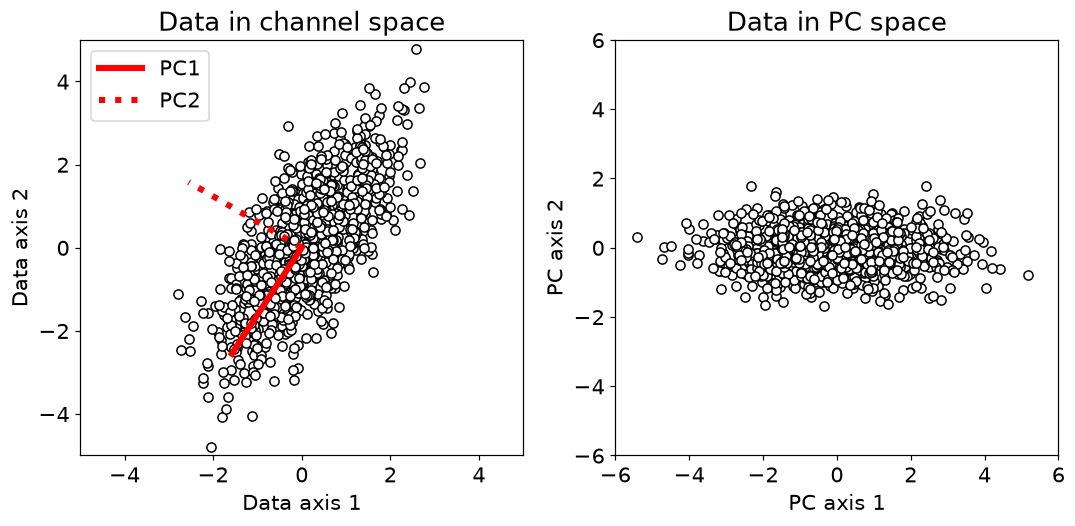

In [3]:
# Create some correlated data
X = np.random.randn(1000,2)
X[:,1] = np.sum(X,axis=1)

# quick PCA
evals,evecs = np.linalg.eig( np.cov(X.T,ddof=1) )
scores = X @ evecs


# show in a plot
_,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].plot(X[:,0],X[:,1],'ko',markerfacecolor='w')
axs[0].plot([0,3*evecs[0,1]],[0,3*evecs[1,1]],'r-',linewidth=4,label='PC1')
axs[0].plot([0,3*evecs[0,0]],[0,3*evecs[1,0]],'r:',linewidth=4,label='PC2')
axs[0].axis([-5,5,-5,5])
axs[0].set_xlabel('Data axis 1')
axs[0].set_ylabel('Data axis 2')
axs[0].legend()
axs[0].set_title('Data in channel space')


axs[1].plot(scores[:,1],scores[:,0],'ko',markerfacecolor='w')
axs[1].set_xlabel('PC axis 1')
axs[1].set_ylabel('PC axis 2')
axs[1].axis([-6,6,-6,6])
axs[1].set_title('Data in PC space')

plt.tight_layout()
plt.savefig(ASSET / 'Figure_14_01.png',dpi=140)
plt.show()

### 코드 14-03

- 원본: `original_py/LA4DS_ch14.py` 46–60행.

In [4]:
# Empirical demonstration that variance and squared vector norm are equal.
# You can prove their equivalence by writing down their formulas and assuming the vector is mean-centered.

# extract one variable
q = X[:,1]

# compute variance
var = np.var(q,ddof=1)

# compute squared vector norm (after mean-centering)
norm = np.linalg.norm( q-np.mean(q) )**2

# show that they're the same (with the scaling factor)
print(var)
print(norm / (len(q)-1))

2.0710375494081577
2.071037549408158


## 연습문제 1 · 주가 수익률 PCA

- **목표**: 여러 변수의 공통 변동 방향을 추출합니다.
- **풀이 순서**: 원자료의 평균을 빼고 공분산을 계산합니다. 고윳값을 내림차순으로 정렬하고 점수·분산 비율·가중치를 그립니다.
- **결과 해석**: 첫 성분일수록 분산을 많이 설명합니다. 점수 분산은 대응 고윳값과 같고 서로 다른 점수는 무상관입니다. 가중치 부호 전체 반전은 같은 성분입니다.

### 코드 14-04

- 원본: `original_py/LA4DS_ch14.py` 64–72행.
- **보완**: 이스탄불 주가 수익률 원자료의 로컬 사본을 사용합니다.

In [5]:
# Data citation: Akbilgic, Oguz. (2013). ISTANBUL STOCK EXCHANGE. UCI Machine Learning Repository.
# data source website: https://archive-beta.ics.uci.edu/ml/datasets/istanbul+stock+exchange

# import the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00247/data_akbilgic.xlsx"
data = pd.read_excel(DATA / 'data_akbilgic.xlsx',index_col=0,skiprows=1)

# let's have a look
data

Out[5]: 
                 ISE     ISE.1        SP  ...   BOVESPA        EU        EM
date                                      ...                              
2009-01-05  0.035754  0.038376 -0.004679  ...  0.031190  0.012698  0.028524
2009-01-06  0.025426  0.031813  0.007787  ...  0.018920  0.011341  0.008773
2009-01-07 -0.028862 -0.026353 -0.030469  ... -0.035899 -0.017073 -0.020015
2009-01-08 -0.062208 -0.084716  0.003391  ...  0.028283 -0.005561 -0.019424
2009-01-09  0.009860  0.009658 -0.021533  ... -0.009764 -0.010989 -0.007802
...              ...       ...       ...  ...       ...       ...       ...
2011-02-16  0.008599  0.013400  0.006238  ...  0.018371  0.006975  0.003039
2011-02-17  0.009310  0.015977  0.003071  ...  0.001686 -0.000581  0.001039
2011-02-18  0.000191 -0.001653  0.001923  ...  0.005628  0.000572  0.006938
2011-02-21 -0.013069 -0.013706 -0.020742  ... -0.011942 -0.012615 -0.000958
2011-02-22 -0.007246 -0.019442  0.000000  ... -0.012252 -0.005465 -0.014297

[5

D:\Linear_Algebra\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


### 코드 14-05

- 원본: `original_py/LA4DS_ch14.py` 74–77행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

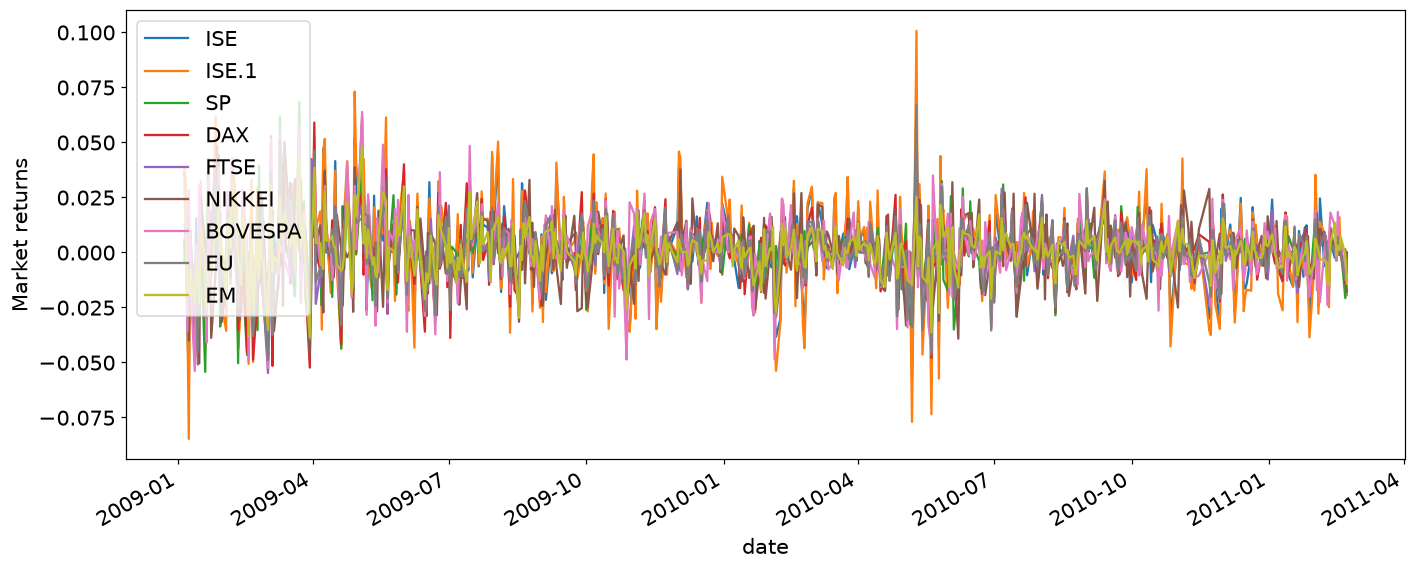

In [6]:
# show some data in line plots
data.plot(figsize=(15,6),ylabel='Market returns')
plt.savefig(ASSET / 'Figure_14_03a.png',dpi=140)
plt.show()

### 코드 14-06

- 원본: `original_py/LA4DS_ch14.py` 79–82행.

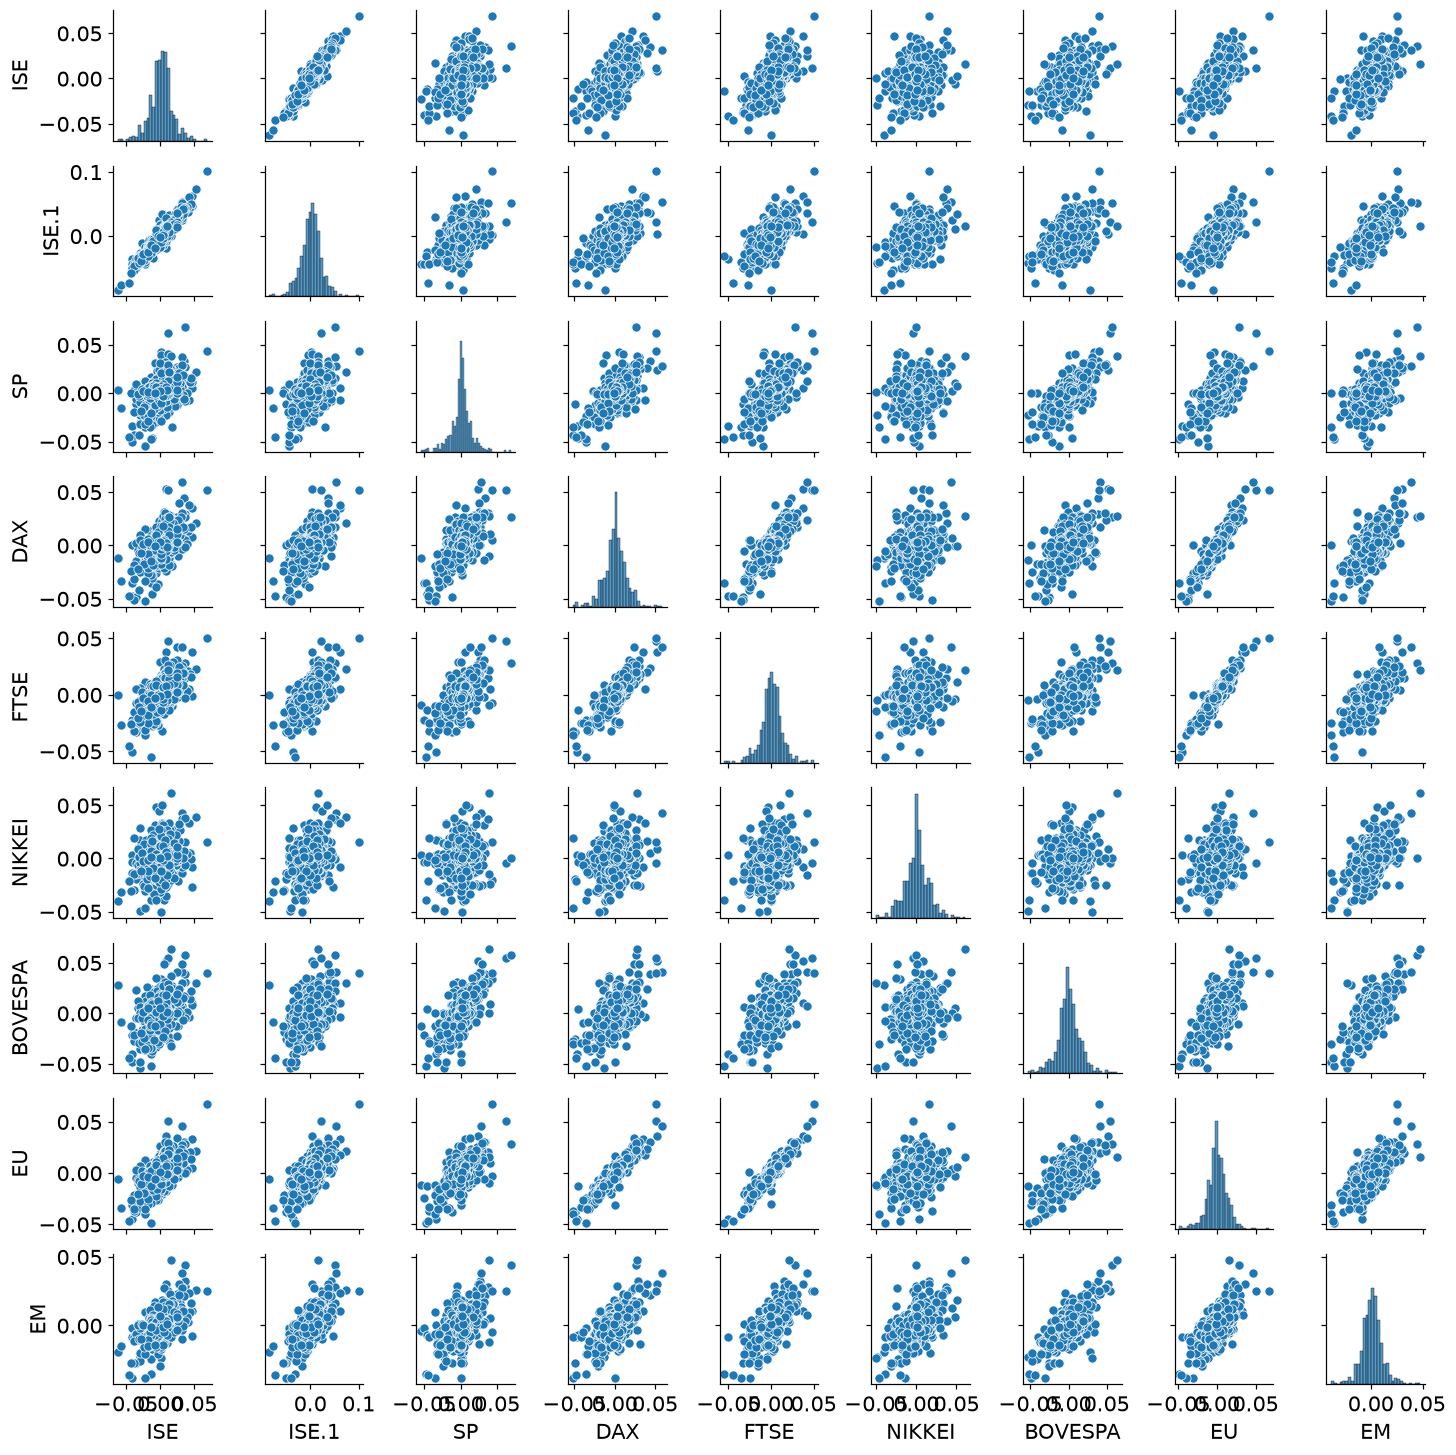

In [7]:
# Seaborn's pairplot shows a lot of positive correlations
# I don't show this in the book b/c it's too big, lol.
sns.pairplot(data,height=1.5)
plt.show()

### 코드 14-07

- 원본: `original_py/LA4DS_ch14.py` 84–89행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

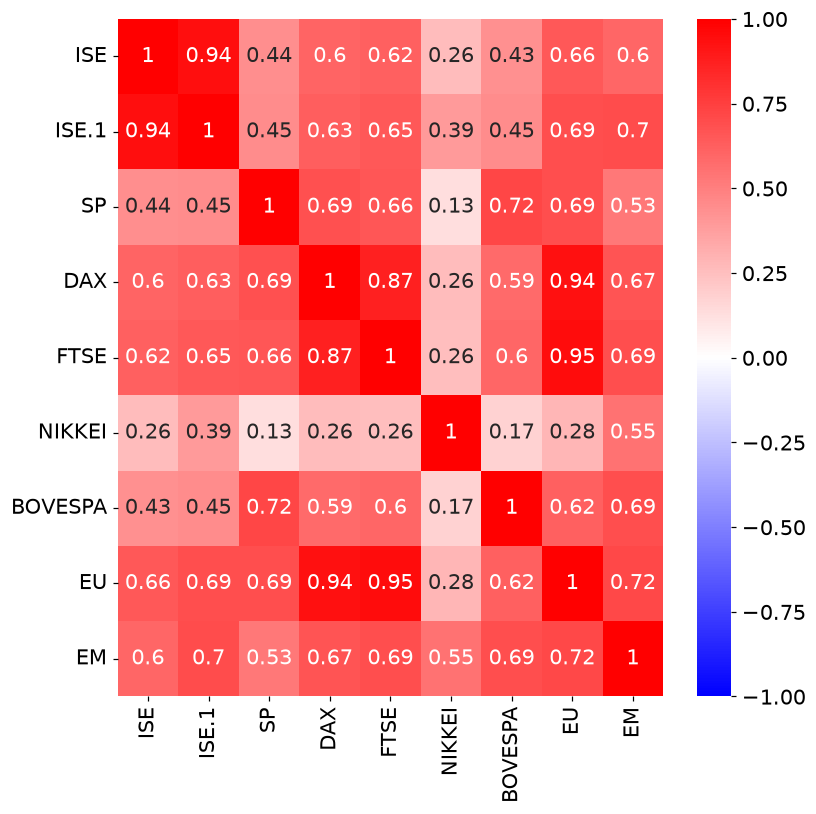

In [8]:
### show the correlation matrix in an image

plt.figure(figsize=(8,8))
heatmap = sns.heatmap(data.corr(),vmin=-1,vmax=1,annot=True,cmap='bwr')
plt.savefig(ASSET / 'Figure_14_03b.png',dpi=140)
plt.show()

### 코드 14-08

- 원본: `original_py/LA4DS_ch14.py` 93–110행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

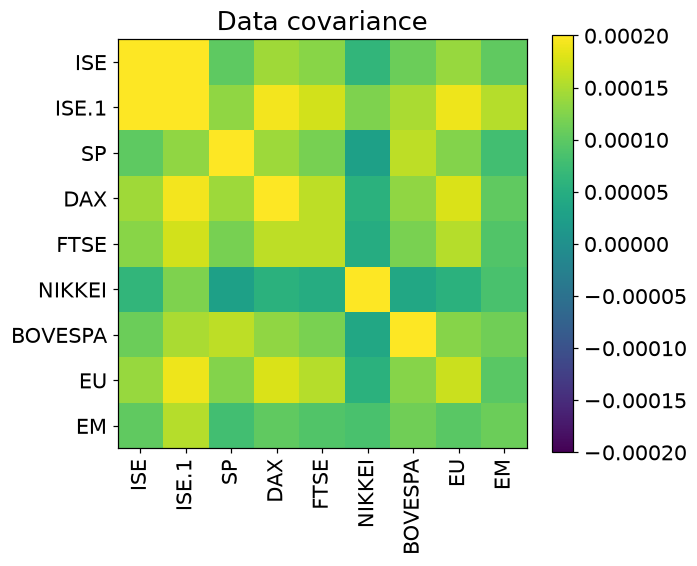

In [9]:
#### now for PCA!

# Step 1: covariance matrix
X = data.values # extract data
X = X - np.mean(X,axis=0,keepdims=True) # mean-center via broadcasting

# note: these data are observations-by-features, so we need X'X, not XX'
covmat = X.T@X / (X.shape[0]-1)

# visualize it
plt.figure(figsize=(6,6))
plt.imshow(covmat,vmin=-.0002,vmax=.0002)
plt.colorbar(shrink=.82)
plt.title('Data covariance')
plt.xticks(range(X.shape[1]),labels=data.columns,rotation=90)
plt.yticks(range(X.shape[1]),labels=data.columns)
plt.savefig(ASSET / 'Figure_14_03c.png',dpi=140)
plt.show()

### 코드 14-09

- 원본: `original_py/LA4DS_ch14.py` 112–136행.
- **보완**: 대칭 공분산 행렬에 eigh를 사용해 실수 고윳값과 직교기저를 구합니다.
- **보완**: PCA 점수를 중심화한 데이터로 계산합니다.

(536, 2)


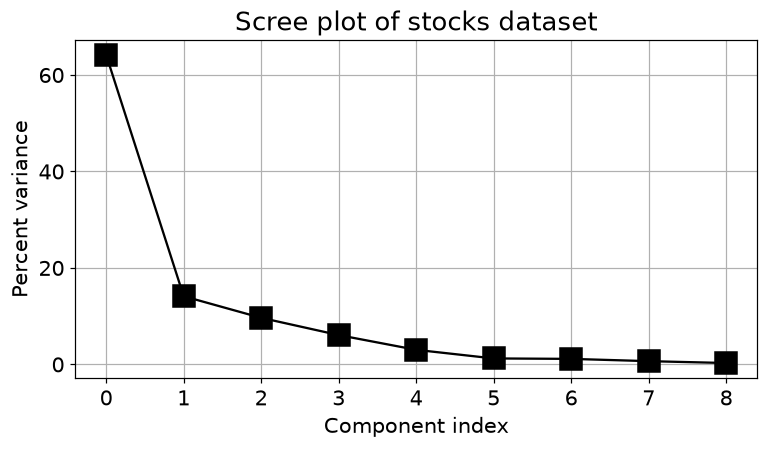

In [10]:
# Step 2: eigendecomposition
evals,evecs = np.linalg.eigh(covmat)

# Step 3: sort results
sidx  = np.argsort(evals)[::-1]
evals = evals[sidx]
evecs = evecs[:,sidx]


# Step 4: component scores
components = X @ evecs[:,0:2]
print(components.shape)

# Step 5: eigenvalues to %var
factorScores = 100*evals/np.sum(evals)


# show scree plot
plt.figure(figsize=(8,4))
plt.plot(factorScores,'ks-',markersize=15)
plt.xlabel('Component index')
plt.ylabel('Percent variance')
plt.title('Scree plot of stocks dataset')
plt.grid()
plt.show()

### 코드 14-10

- 원본: `original_py/LA4DS_ch14.py` 138–143행.

In [11]:
# Show that variance of the components equals the eigenvalue
print('Variance of first two components:')
print(np.var(components,axis=0,ddof=1)) # note the ddof=1! The default produces the biased variance.

print(f'\nFirst two eigenvalues:')
print(evals[:2])

Variance of first two components:
[0.001301 0.000286]

First two eigenvalues:
[0.001301 0.000286]


### 코드 14-11

- 원본: `original_py/LA4DS_ch14.py` 145–152행.

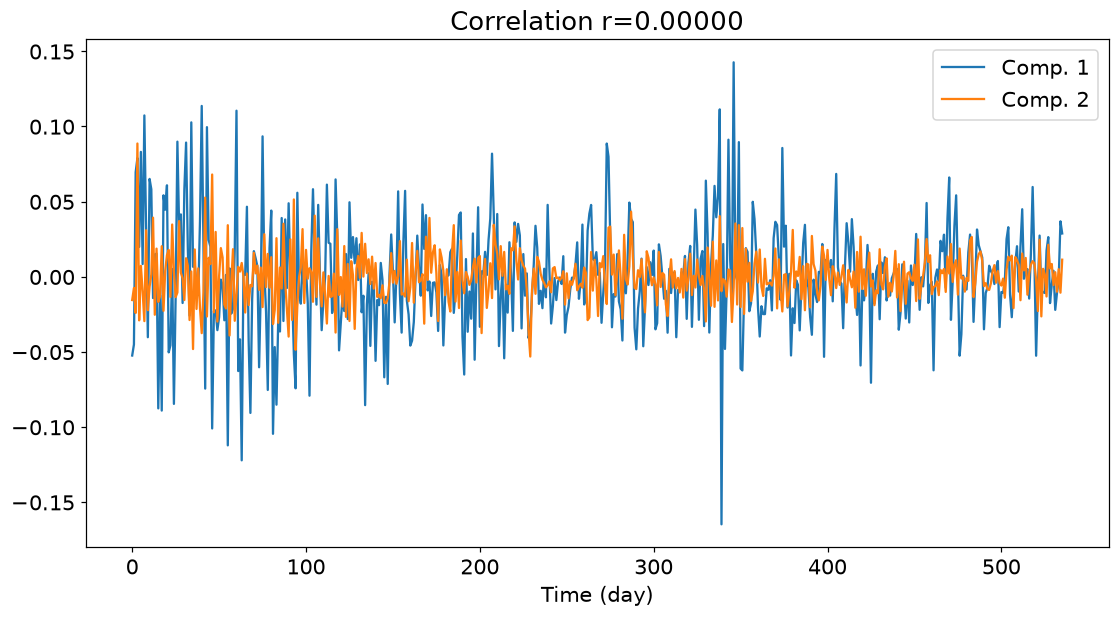

In [12]:
# correlate first two components

plt.figure(figsize=(12,6))
plt.plot(components)
plt.xlabel('Time (day)')
plt.legend(['Comp. 1','Comp. 2'])
plt.title(f'Correlation r={np.corrcoef(components.T)[0,1]:.5f}')
plt.show()

### 코드 14-12

- 원본: `original_py/LA4DS_ch14.py` 154–164행.

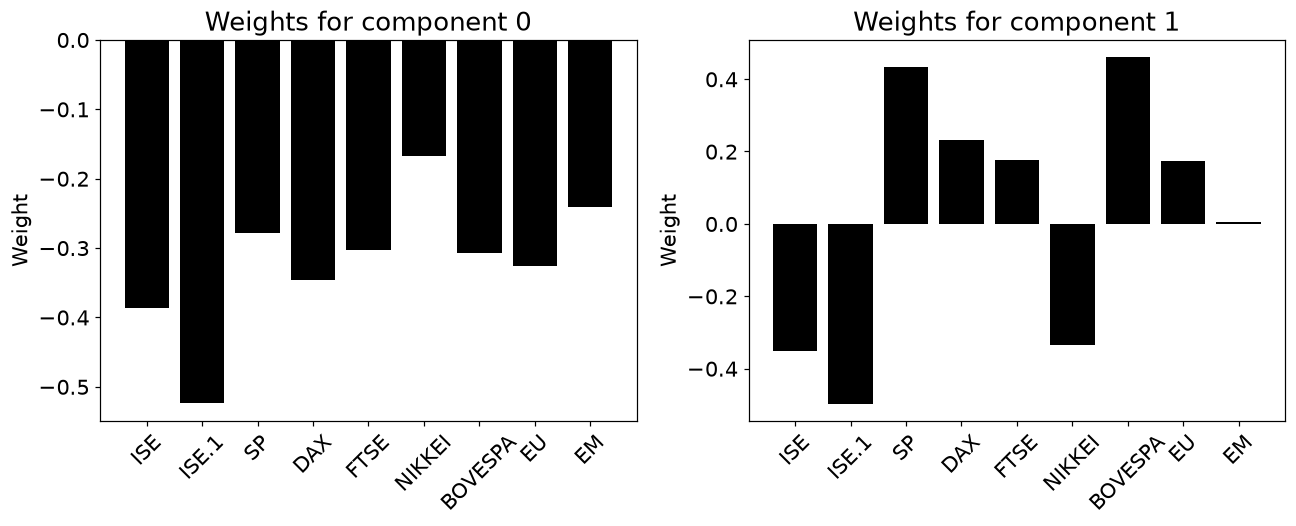

In [13]:
_,axs = plt.subplots(1,2,figsize=(12,5))

for i in range(2):
  axs[i].bar(range(X.shape[1]),evecs[:,i],color='black')
  axs[i].set_xticks(range(X.shape[1]))
  axs[i].set_xticklabels(data.columns,rotation=45)
  axs[i].set_ylabel('Weight')
  axs[i].set_title(f'Weights for component {i}')

plt.tight_layout()
plt.show()

### 코드 14-13

- 원본: `original_py/LA4DS_ch14.py` 166–201행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

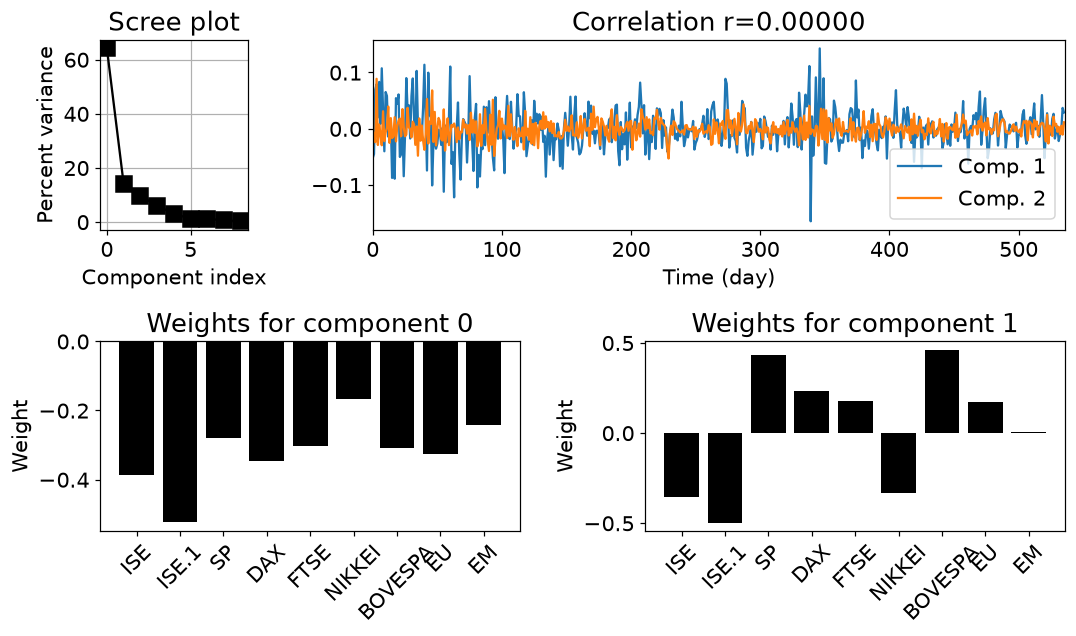

In [14]:
# Now all in one figure

fig = plt.figure(figsize=(10,6))
gs = GridSpec(2,4,figure=fig)

# scree plot
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(factorScores,'ks-',markersize=10)
ax1.set_xlabel('Component index')
ax1.set_ylabel('Percent variance')
ax1.set_title('Scree plot')
ax1.grid()


# component time series
ax2 = fig.add_subplot(gs[0,1:])
ax2.plot(components)
ax2.set_xlabel('Time (day)')
ax2.set_xlim([0,components.shape[0]])
ax2.legend(['Comp. 1','Comp. 2'])
ax2.set_title(f'Correlation r={np.corrcoef(components.T)[0,1]:.5f}')


# bar plots of component loadings
axs = fig.add_subplot(gs[1,:2]), fig.add_subplot(gs[1,2:])
for i in range(2):
  axs[i].bar(range(X.shape[1]),evecs[:,i],color='black')
  axs[i].set_xticks(range(X.shape[1]))
  axs[i].set_xticklabels(data.columns,rotation=45)
  axs[i].set_ylabel('Weight')
  axs[i].set_title(f'Weights for component {i}')


plt.tight_layout()
plt.savefig(ASSET / 'Figure_14_04.png',dpi=140)
plt.show()

## 연습문제 2 · 공분산 SVD와 데이터 SVD

- **목표**: PCA를 두 경로로 계산합니다.
- **풀이 순서**: 공분산의 SVD는 고윳값과 s를 비교하고, 중심화 데이터의 SVD는 s²/(N-1)을 고윳값과 비교합니다.
- **결과 해석**: 공분산의 U와 데이터의 V가 PCA 방향에 대응합니다. 어느 행렬을 분해했는지에 따라 비교 대상이 달라집니다.

### 코드 14-14

- 원본: `original_py/LA4DS_ch14.py` 205–226행.

In [15]:
### SVD on covariance matrix

# It suffices to show that the eigenvalues and singular values match, and that the eigenvectors and singular vectors match.
# Here I only show the first four values and the first vector.

# SVD
U,s,Vt = np.linalg.svd(covmat)

# eigen/singular values
print('First 4 eigenvalues:')
print(evals[:4])

print(f'\nFirst 4 singular values:')
print(s[:4])


# eigen/singular vectors
print('\n\n\nFirst eigenvector:')
print(evecs[:,0])

print('\nFirst singular vector:')
print(U[:,0])

First 4 eigenvalues:
[0.001301 0.000286 0.000195 0.000123]

First 4 singular values:
[0.001301 0.000286 0.000195 0.000123]



First eigenvector:
[-0.386485 -0.52391  -0.278605 -0.346215 -0.303225 -0.167818 -0.307419
 -0.325441 -0.241113]

First singular vector:
[-0.386485 -0.52391  -0.278605 -0.346215 -0.303225 -0.167818 -0.307419
 -0.325441 -0.241113]


### 코드 14-15

- 원본: `original_py/LA4DS_ch14.py` 228–250행.

In [16]:
### SVD on data matrix

# Again, we can simply show that the singular values (suitably normalized) match the eigenvalues, and that
# the singular vectors match the eigenvectors.

# Note that the data variable X is already mean-centered!
U,s,Vt = np.linalg.svd(X)  # SVD


# eigen/singular values
print('First 4 eigenvalues:')
print(evals[:4])

print(f'\nFirst 4 singular values:')
print(s[:4]**2/(X.shape[0]-1))


# eigen/singular vectors
print('\n\n\nFirst eigenvector:')
print(evecs[:,0])

print('\nFirst right singular vector:')
print(Vt[0,:])

First 4 eigenvalues:
[0.001301 0.000286 0.000195 0.000123]

First 4 singular values:
[0.001301 0.000286 0.000195 0.000123]



First eigenvector:
[-0.386485 -0.52391  -0.278605 -0.346215 -0.303225 -0.167818 -0.307419
 -0.325441 -0.241113]

First right singular vector:
[-0.386485 -0.52391  -0.278605 -0.346215 -0.303225 -0.167818 -0.307419
 -0.325441 -0.241113]


## 연습문제 3 · sklearn PCA 검증

- **목표**: 직접 구현한 PCA와 라이브러리를 비교합니다.
- **풀이 순서**: PCA를 적합하고 explained_variance_와 components_를 앞의 고유분해 결과와 대조합니다.
- **결과 해석**: 설명분산은 일치하고 방향은 부호 차이가 있을 수 있습니다. sklearn components_는 방향을 행으로 저장합니다.

### 코드 14-16

- 원본: `original_py/LA4DS_ch14.py` 254–275행.

In [17]:
### As above, it suffices to show that the eigenvalues and eigenvectors match.

from sklearn.decomposition import PCA
 
pca = PCA()
X_t = pca.fit_transform(data)

# compare percent-normalized eigenvalues
print('Eigenvalues:')
print(evals[:4])

print(f'\nExplained variance from sklearn:')
print(pca.explained_variance_[:4])



# eigenvector and sklearn component
print('\n\n\nFirst eigenvector:')
print(evecs[:,0])

print('\nFirst sklearn component vector:')
print(pca.components_[0,:])

Eigenvalues:
[0.001301 0.000286 0.000195 0.000123]

Explained variance from sklearn:
[0.001301 0.000286 0.000195 0.000123]



First eigenvector:
[-0.386485 -0.52391  -0.278605 -0.346215 -0.303225 -0.167818 -0.307419
 -0.325441 -0.241113]

First sklearn component vector:
[0.386485 0.52391  0.278605 0.346215 0.303225 0.167818 0.307419 0.325441
 0.241113]


## 연습문제 4 · 겹친 방향의 PCA

- **목표**: 데이터에 두 줄 구조가 있어도 PCA가 각각을 찾는지 살펴봅니다.
- **풀이 순서**: 좁고 긴 난수 점들을 두 각도로 회전해 합친 후 SVD를 적용해 주방향을 그립니다.
- **결과 해석**: PCA는 전체 분산 기준의 직교 방향을 구합니다. 두 군집의 실제 방향을 각각 분리하는 알고리즘은 아닙니다. Vt의 행 인덱싱을 바로잡았습니다.

### 코드 14-17

- 원본: `original_py/LA4DS_ch14.py` 279–293행.

In [18]:
# generate data

x = np.hstack((np.random.randn(1000,1),.05*np.random.randn(1000,1)))

# rotation matrices
th = -np.pi/6
R1 = np.array([ [np.cos(th), -np.sin(th)],
                [np.sin(th),  np.cos(th)] ])
th = -np.pi/3
R2 = np.array([ [np.cos(th), -np.sin(th)],
                [np.sin(th),  np.cos(th)] ])

# create the data
X = np.vstack((x@R1,x@R2))
X.shape

Out[18]: (2000, 2)


### 코드 14-18

- 원본: `original_py/LA4DS_ch14.py` 295–302행.

In [19]:
# PCA via SVD
U,s,Vt = np.linalg.svd(X-np.mean(X,axis=0,keepdims=True))

# not necessary: convert singular values into eigenvalues
s = s**2 / (X.shape[0]-1)

# also not necessary: up-scale the singular vectors for visualization
Vt *= 2

### 코드 14-19

- 원본: `original_py/LA4DS_ch14.py` 304–318행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: Vt의 행이 주성분 방향이므로 그림 좌표를 수정했습니다.
- **보완**: 두 번째 주성분 방향의 좌표를 수정했습니다.

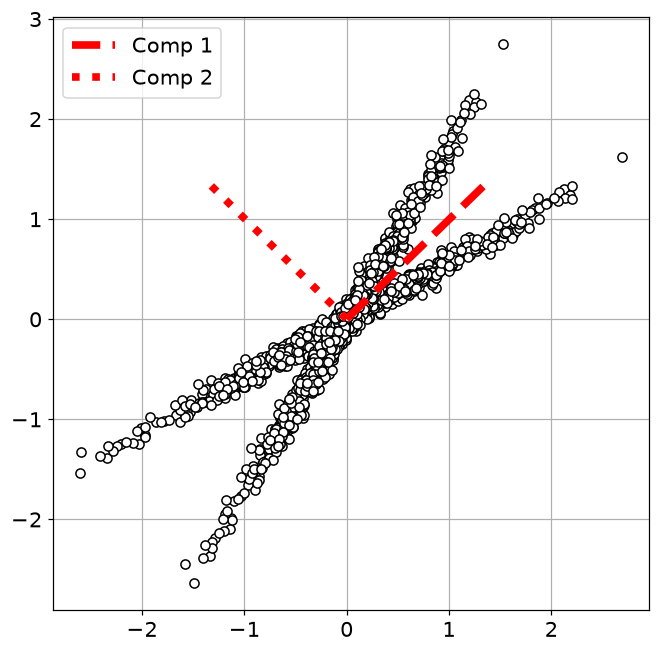

In [20]:
# plot the data and eigenvectors

plt.figure(figsize=(7,7))

# the data
plt.plot(X[:,0],X[:,1],'ko',markerfacecolor='w')

# eigenvectors
plt.plot([0,Vt[0,0]],[0,Vt[0,1]],'r--',linewidth=5,label='Comp 1')
plt.plot([0,Vt[1,0]],[0,Vt[1,1]],'r:',linewidth=5,label='Comp 2')

plt.legend()
plt.grid()
plt.savefig(ASSET / 'Figure_14_05.png',dpi=140)
plt.show()

## 연습문제 5 · 분류용 데이터 만들기

- **목표**: 집단 내 공분산과 집단 평균 차이를 구분합니다.
- **풀이 순서**: 두 클래스에 같은 상관 구조를 주고 한 클래스 평균을 이동시켜 산점도와 밀도를 그립니다.
- **결과 해석**: 점들이 길게 퍼지는 방향과 두 집단을 나누기 좋은 방향이 다를 수 있습니다. 다음 LDA의 입력 데이터가 됩니다.

### 코드 14-20

- 원본: `original_py/LA4DS_ch14.py` 322–344행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

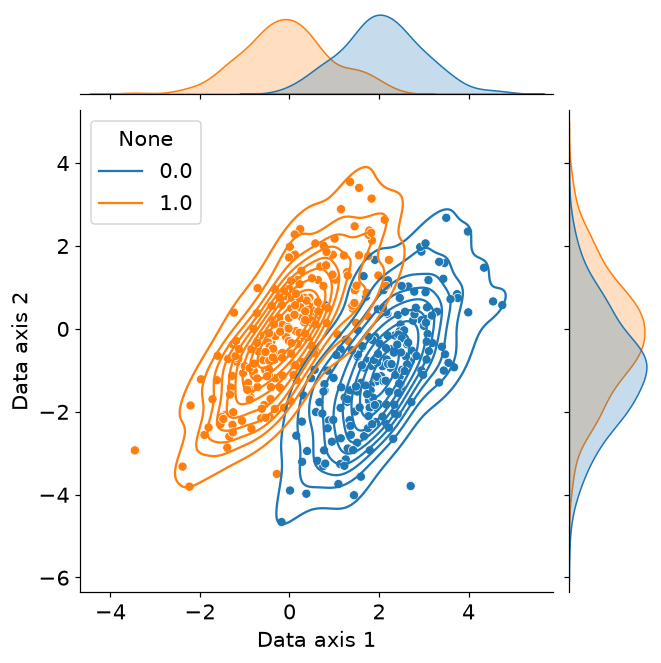

In [21]:
# create the data
N = 200

class1 = np.random.randn(N,2)
class1[:,1] += class1[:,0]
class1 += np.array([2,-1])

class2 = np.random.randn(N,2)
class2[:,1] += class2[:,0]

# for later, it will be convenient to have the data in one matrix
alldata = np.vstack((class1,class2))
labels  = np.append(np.zeros(N),np.ones(N))



# show data in their original data space
ax = sns.jointplot(x=alldata[:,0],y=alldata[:,1],hue=labels)
ax.ax_joint.set_xlabel('Data axis 1')
ax.ax_joint.set_ylabel('Data axis 2')
ax.plot_joint(sns.kdeplot)
plt.savefig(ASSET / 'Figure_14_02a.png',dpi=140)
plt.show()

## 연습문제 6 · 일반화 고유분해로 LDA

- **목표**: 집단 간·내 공분산 비율을 최대화하는 방향을 구합니다.
- **풀이 순서**: 평균들로 SB, 집단별 공분산 평균으로 SW를 만들고 eigh(SB,SW)를 풉니다. 점수를 계산하고 클래스 평균으로 부호·경계를 결정합니다.
- **결과 해석**: 첫 방향에서 클래스가 잘 분리됩니다. 여기에 출력한 정확도는 학습 정확도입니다. 클래스 1을 점수 양수로 고정하는 원본의 부호 의존성을 보완했습니다.

### 코드 14-21

- 원본: `original_py/LA4DS_ch14.py` 348–372행.

In [22]:
# LDA

# between-class covariance
cmc1 = np.mean(class1,axis=0)
cmc2 = np.mean(class2,axis=0)
covB = np.cov(np.vstack((cmc1,cmc2)).T,ddof=1)

# within-class covariances
cov1 = np.cov(class1.T,ddof=1)
cov2 = np.cov(class2.T,ddof=1)
covW = (cov1+cov2)/2


# LDA via GED
from scipy.linalg import eigh
evals,evecs = eigh(covB,covW)

# sort the solution
sidx  = np.argsort(evals)[::-1]
evals = evals[sidx]
evecs = evecs[:,sidx]


# project the mean-centered data onto the GED axes
projA = (alldata-np.mean(alldata,axis=0)) @ evecs  # A=all

### 코드 14-22

- 원본: `original_py/LA4DS_ch14.py` 374–404행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

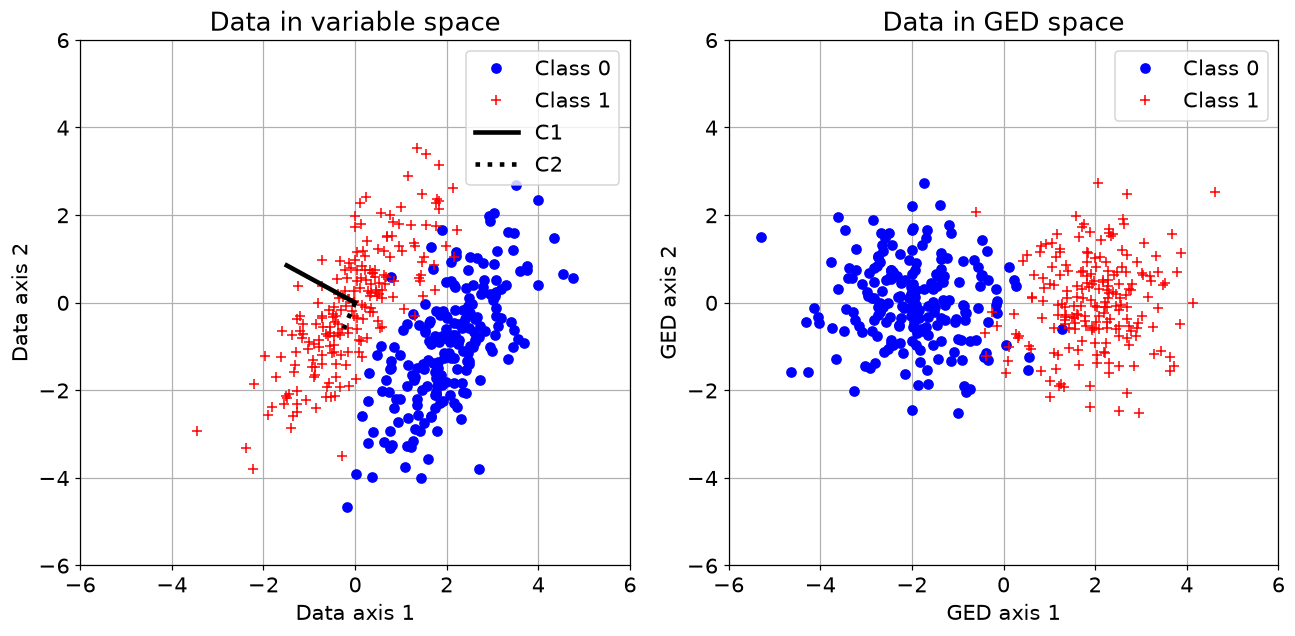

In [23]:
# show the data
_,axs = plt.subplots(1,2,figsize=(12,6))
marker = ['bo','r+']
for i in range(2):
  axs[0].plot(alldata[labels==i,0],alldata[labels==i,1],marker[i],label=f'Class {i}')

axs[0].plot([0,evecs[0,0]],[0,evecs[1,0]],'k-',linewidth=3,label='C1')
axs[0].plot([0,evecs[0,1]],[0,evecs[1,1]],'k:',linewidth=3,label='C2')
axs[0].set_xlabel('Data axis 1')
axs[0].set_ylabel('Data axis 2')
axs[0].set_title('Data in variable space')



# and again in the GED space
for i in range(2):
  axs[1].plot(projA[labels==i,0],projA[labels==i,1],marker[i],label=f'Class {i}')
axs[1].set_xlabel('GED axis 1')
axs[1].set_ylabel('GED axis 2')
axs[1].set_title('Data in GED space')


# common settings
for i in range(2):
  axs[i].axis([-6,6,-6,6])
  axs[i].grid()
  axs[i].legend()

plt.tight_layout()
plt.savefig(ASSET / 'Figure_14_06ab.png',dpi=140)
plt.show()

### 코드 14-23

- 원본: `original_py/LA4DS_ch14.py` 406–420행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: 고유벡터 부호에 따라 클래스가 뒤집히지 않도록 학습 클래스 평균으로 방향과 경계를 정합니다.

Prediction accuracy: 97.0%


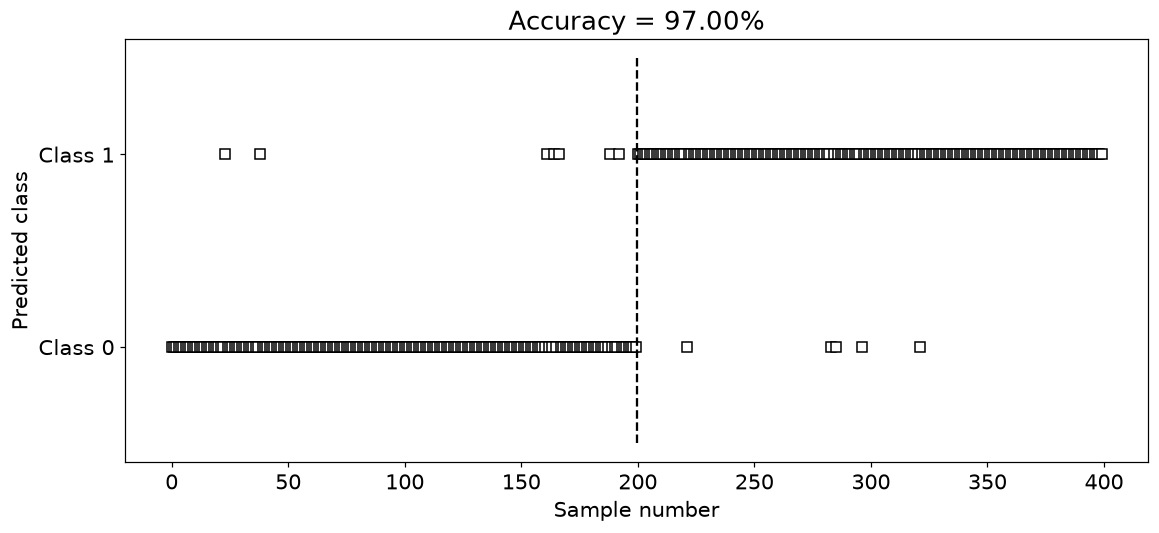

In [24]:
# prediction (converted to ints)
score = projA[:,0]
mid = (score[labels==0].mean()+score[labels==1].mean())/2
positive_is_one = score[labels==1].mean() > score[labels==0].mean()
predictedLabel = ((score > mid) if positive_is_one else (score < mid)).astype(int)

print(f'Prediction accuracy: {100*np.mean( predictedLabel==labels )}%')

# show the results
plt.figure(figsize=(12,5))
plt.plot(predictedLabel,'ks',markersize=7,markerfacecolor='w',linewidth=2)
plt.plot([N-.5,N-.5],[-.5,1.5],'k--')
plt.xlabel('Sample number')
plt.ylabel('Predicted class')
plt.yticks([0,1],labels=['Class 0','Class 1'])
plt.title(f'Accuracy = {100*np.mean(predictedLabel==labels):.2f}%')
plt.savefig(ASSET / 'Figure_14_06c.png',dpi=140)
plt.show()

### 코드 14-24

- 원본: `original_py/LA4DS_ch14.py` 422–428행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

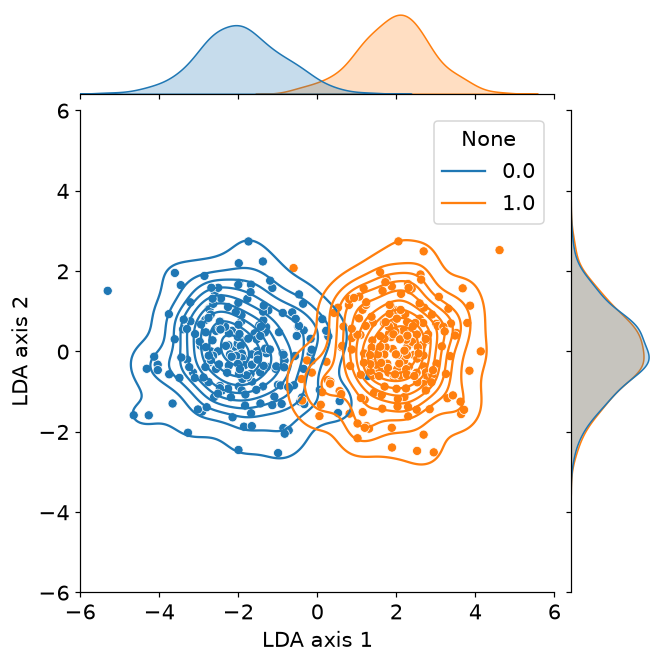

In [25]:
# redraw the jointplot in the GED space (used in Figure 2)
ax = sns.jointplot(x=projA[:,0],y=projA[:,1],hue=labels,xlim=[-6,6],ylim=[-6,6])
ax.ax_joint.set_xlabel('LDA axis 1')
ax.ax_joint.set_ylabel('LDA axis 2')
ax.plot_joint(sns.kdeplot)
plt.savefig(ASSET / 'Figure_14_02b.png',dpi=140)
plt.show()

## 연습문제 7 · LDA 방향의 내적

- **목표**: 일반화 고유벡터가 어떤 척도에서 직교정규인지 확인합니다.
- **풀이 순서**: VtV와 VtSWV를 비교합니다.
- **결과 해석**: 보통 VtV는 항등행렬이 아니고 VtSWV는 항등행렬입니다. 일반화 고유분해에서의 정규화 정의를 보여 줍니다.

### 코드 14-25

- 원본: `original_py/LA4DS_ch14.py` 432–439행.

In [26]:
# not the identity matrix!
print("V'V:")
print(np.round( evecs.T @ evecs ,3))


# yes the identity matrix!
print(f"\nV'RV:")
print(np.round( evecs.T @ covW @ evecs ,3))

V'V:
[[ 2.945 -0.136]
 [-0.136  0.414]]

V'RV:
[[ 1. -0.]
 [-0.  1.]]


## 연습문제 8 · sklearn LDA와 비교

- **목표**: 직접 구현한 분류와 라이브러리 분류를 대조합니다.
- **풀이 순서**: 같은 데이터에 eigen 솔버 LDA를 적합하고 예측 라벨을 함께 그립니다.
- **결과 해석**: 대부분 비슷한 결과를 보입니다. 공분산 추정·사전확률·경계 구성에 따라 완전 일치는 보장하지 않습니다. 비교는 같은 학습 데이터 기준입니다.

### 코드 14-26

- 원본: `original_py/LA4DS_ch14.py` 443–461행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

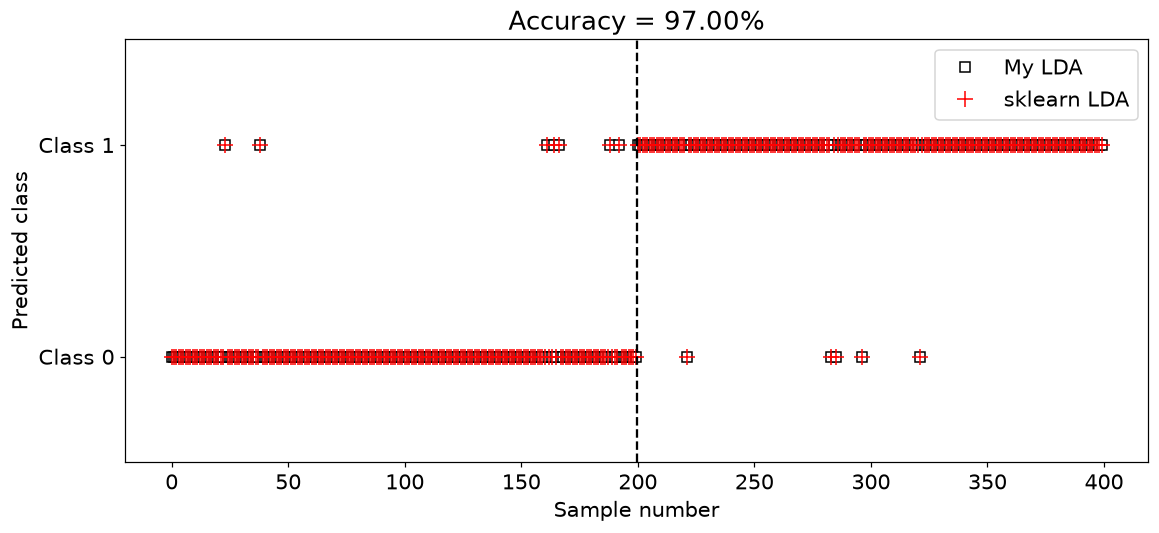

In [27]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

ldamodel = LDA(solver='eigen')
ldamodel.fit(alldata,labels)


# show the results
plt.figure(figsize=(12,5))
plt.plot(predictedLabel,'ks',markersize=7,markerfacecolor='w',linewidth=2,label='My LDA')
plt.plot(ldamodel.predict(alldata),'r+',markersize=10,markerfacecolor='w',linewidth=2,label='sklearn LDA')
plt.plot([N-.5,N-.5],[-.5,1.5],'k--')
plt.xlabel('Sample number')
plt.ylabel('Predicted class')
plt.yticks([0,1],labels=['Class 0','Class 1'])
plt.ylim([-.5,1.5])
plt.legend()
plt.title(f'Accuracy = {100*np.mean(ldamodel.predict(alldata)==labels):.2f}%')
plt.savefig(ASSET / 'Figure_14_07.png',dpi=140)
plt.show()

## 연습문제 9 · shrinkage 검증

- **목표**: 공분산 정규화 강도의 영향을 검증 표본에서 봅니다.
- **풀이 순서**: 21개 강도에 같은 50개 무작위 분할을 사용합니다. 각 분할에서 350개 학습·50개 검증 표본으로 정확도를 구해 평균냅니다.
- **결과 해석**: 너무 강한 정규화는 필요한 방향 정보도 지울 수 있습니다. 최적 강도는 데이터에 따라 달라지고 검증 곡선을 보고 선택한 성능에는 선택 편향이 있습니다.

### 코드 14-27

- 원본: `original_py/LA4DS_ch14.py` 465–498행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: 모든 shrinkage 값에 같은 학습/검증 분할을 적용합니다.
- **보완**: 분할 인덱스를 사용합니다.
- **보완**: 검증 표본 변동과 shrinkage 효과를 분리합니다.

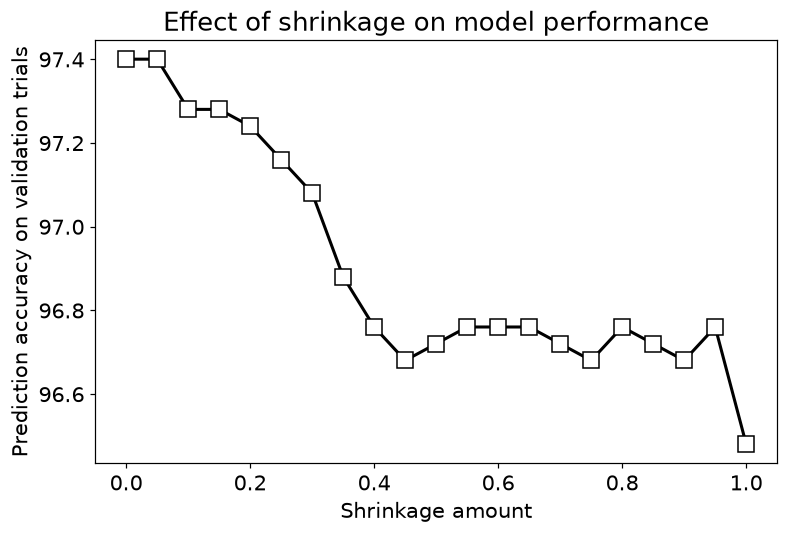

In [28]:
# shrinkage amounts
shrinkage = np.linspace(0,1,21)
accuracies = np.zeros(len(shrinkage))

# loop over shrinkages and compute model accuracy
splits = [np.random.permutation(alldata.shape[0]) for _ in range(50)]
for i,s in enumerate(shrinkage):
  
  # setup the model
  ldamodel = LDA(solver='eigen',shrinkage=s)

  tmpacc = []
  for split_i in range(50):

    # randomly split the data into train/test
    randorder = splits[split_i]

    # fit the model on the training data
    ldamodel.fit(alldata[randorder[:350],:],labels[randorder[:350]])

    # grab accuracy
    tmpacc.append(100*np.mean(ldamodel.predict(alldata[randorder[350:],:])==labels[randorder[350:]]))

  # evaluate model performance on the test data
  accuracies[i] = np.mean(tmpacc)


# plot!
plt.figure(figsize=(8,5))
plt.plot(shrinkage,accuracies,'ks-',markersize=10,markerfacecolor='w',linewidth=2)
plt.xlabel('Shrinkage amount')
plt.ylabel('Prediction accuracy on validation trials')
plt.title('Effect of shrinkage on model performance')
plt.savefig(ASSET / 'Figure_14_08.png',dpi=140)
plt.show()

## 연습문제 10 · 이미지 SVD와 층

- **목표**: 직접 생성한 도형 이미지를 행렬로 분해합니다.
- **풀이 순서**: RGB를 회색조로 바꾸고 SVD를 구합니다. 특잇값 곡선, 첫 네 랭크 1 층과 누적합을 그립니다.
- **결과 해석**: 큰 밝기 구조가 먼저 보입니다. 원본 링크가 끊겨 입력을 바꿨으므로 책의 이미지·특잇값과 동일한 결과가 아닙니다.

### 코드 14-28

- 원본: `original_py/LA4DS_ch14.py` 502–512행.
- **보완**: 접속 불가인 원본 Picasso 이미지 대신 직접 생성한 도형 이미지를 사용합니다. 뒤의 압축·잡음 제거 수치는 이 대체 이미지 결과입니다.

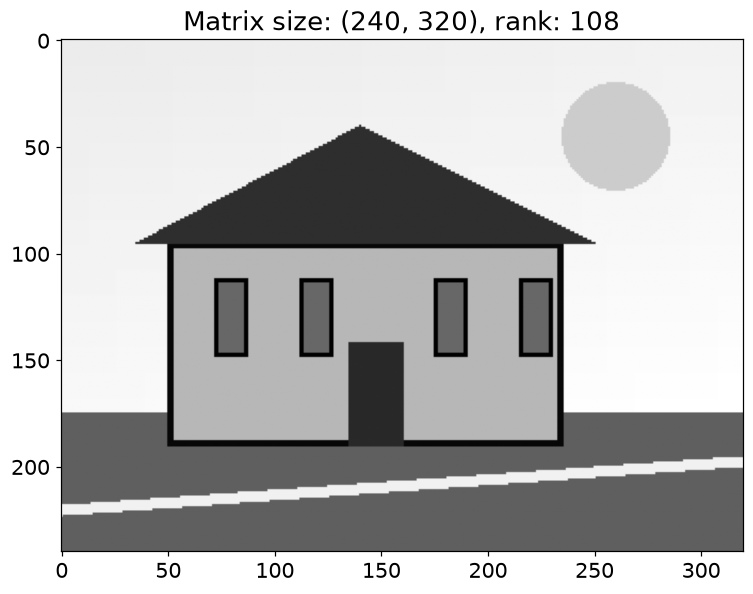

In [29]:
from skimage import io,color
url = 'https://upload.wikimedia.org/wikipedia/en/1/1c/Stravinsky_picasso.png'

# import picture and downsample to 2D
strav = io.imread(DATA / 'generated_scene.png')
strav = color.rgb2gray(strav)

plt.figure(figsize=(8,8))
plt.imshow(strav,cmap='gray')
plt.title(f'Matrix size: {strav.shape}, rank: {np.linalg.matrix_rank(strav)}')
plt.show()

### 코드 14-29

- 원본: `original_py/LA4DS_ch14.py` 514–526행.
- **보완**: 입력 이미지와 일치하도록 표시 문구를 수정했습니다.

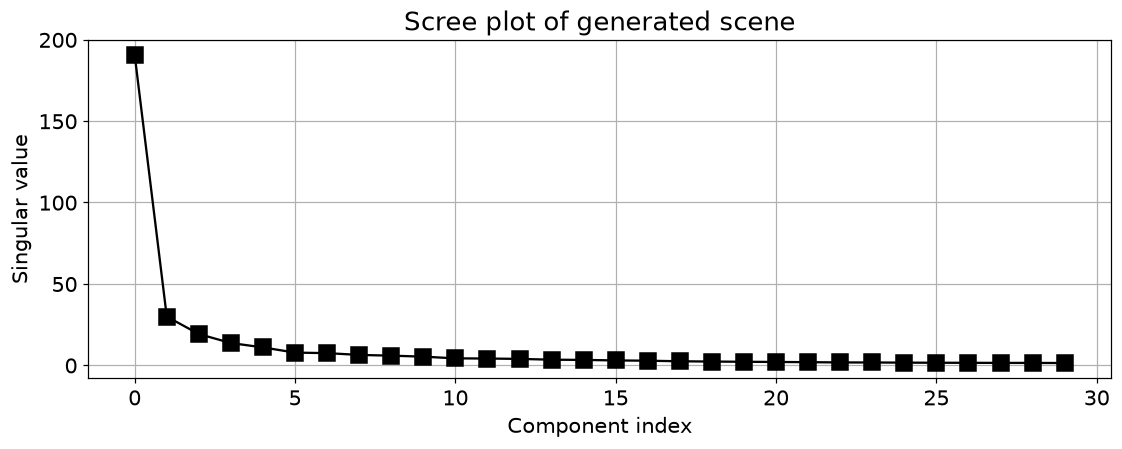

In [30]:
# SVD
U,s,Vt = np.linalg.svd(strav)
S = np.zeros_like(strav)
np.fill_diagonal(S,s)

# show scree plot
plt.figure(figsize=(12,4))
plt.plot(s[:30],'ks-',markersize=10)
plt.xlabel('Component index')
plt.ylabel('Singular value')
plt.title('Scree plot of generated scene')
plt.grid()
plt.show()

### 코드 14-30

- 원본: `original_py/LA4DS_ch14.py` 528–571행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: 입력 이미지와 일치하도록 표시 문구를 수정했습니다.

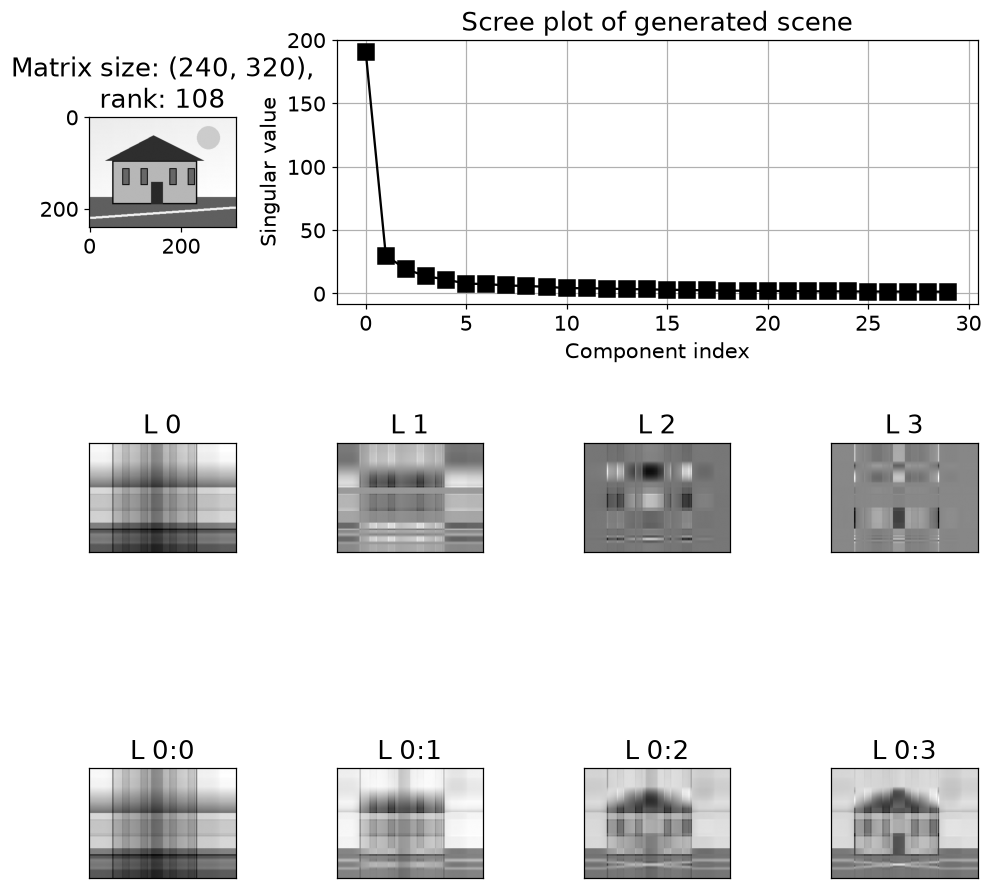

In [31]:
fig = plt.figure(figsize=(9,9))
gs = GridSpec(3,4,figure=fig)

# the image
ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(strav,cmap='gray')
ax1.set_title(f'Matrix size: {strav.shape},\nrank: {np.linalg.matrix_rank(strav)}')

# scree plot
ax2 = fig.add_subplot(gs[0,1:])
ax2.plot(s[:30],'ks-',markersize=10)
ax2.set_xlabel('Component index')
ax2.set_ylabel('Singular value')
ax2.set_title('Scree plot of generated scene')
ax2.grid()


## now show the first N "layers" separately
numLayers = 4
rank1mats = np.zeros((numLayers,strav.shape[0],strav.shape[1]))


# the loop
for i in range(numLayers):
    
    # create this layer
    rank1mats[i,:,:] = np.outer(U[:,i],Vt[i,:])*s[i]
    
    # show this layer
    ax = fig.add_subplot(gs[1,i])
    ax.imshow(rank1mats[i,:,:],cmap='gray')
    ax.set_title(f'L {i}')
    ax.set_xticks([]), ax.set_yticks([])

    # show the cumulative sum of layers
    ax = fig.add_subplot(gs[2,i])
    ax.imshow(np.sum(rank1mats[:i+1,:,:],axis=0),cmap='gray')
    ax.set_title(f'L 0:{i}')
    ax.set_xticks([]), ax.set_yticks([])


plt.tight_layout()
plt.savefig(ASSET / 'Figure_14_09.png',dpi=140)
plt.show()

## 연습문제 11 · 80개 성분으로 압축

- **목표**: 복원 품질과 저장 비용을 함께 계산합니다.
- **풀이 순서**: U의 80열, s의 80개, Vt의 80행으로 복원하고 제곱오차 지도를 봅니다. 각 배열의 nbytes를 비교합니다.
- **결과 해석**: 복원 배열 자체는 원본과 크기가 같습니다. 절약은 분해 인자만 저장할 때 발생하며 표시된 비율은 압축 후 크기/원본 크기입니다.

### 코드 14-31

- 원본: `original_py/LA4DS_ch14.py` 575–598행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

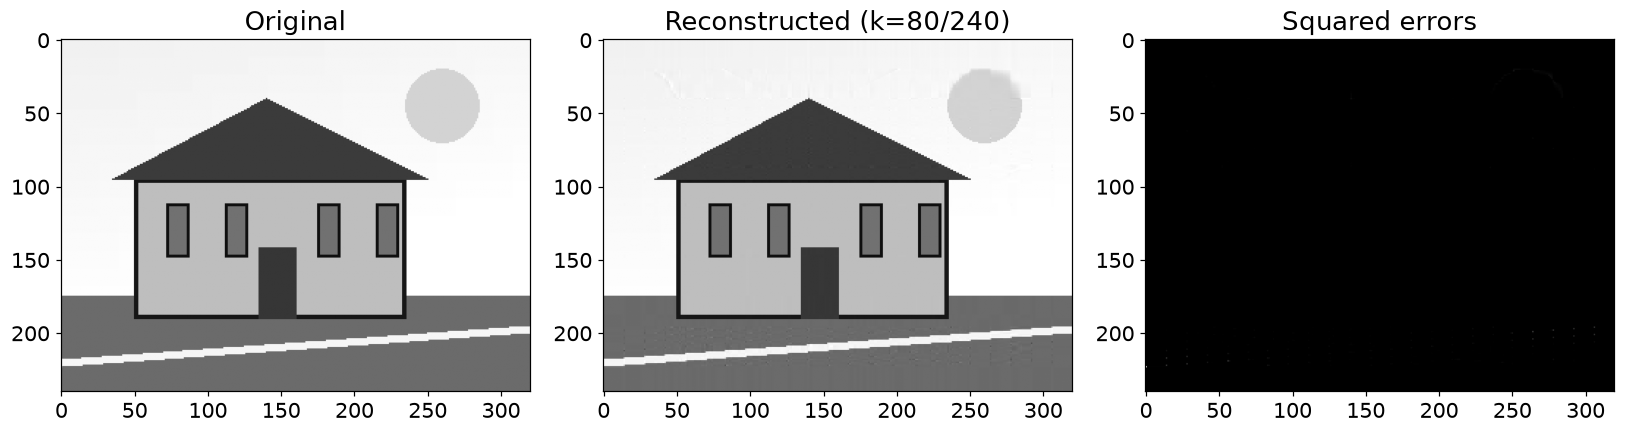

In [32]:
# Reconstruct based on first k layers

# number of components
k = 80

# reconstruction
stravRec = U[:,:k] @ S[:k,:k] @ Vt[:k,:]


# show the original, reconstructed, and error
_,axs = plt.subplots(1,3,figsize=(15,6))

axs[0].imshow(strav,cmap='gray',vmin=.1,vmax=.9)
axs[0].set_title('Original')

axs[1].imshow(stravRec,cmap='gray',vmin=.1,vmax=.9)
axs[1].set_title(f'Reconstructed (k={k}/{len(s)})')

axs[2].imshow((strav-stravRec)**2,cmap='gray',vmin=0,vmax=1e-1)
axs[2].set_title('Squared errors')

plt.tight_layout()
plt.savefig(ASSET / 'Figure_14_10.png',dpi=140)
plt.show()

### 코드 14-32

- 원본: `original_py/LA4DS_ch14.py` 600–615행.

In [33]:
# compute sizes of the images
stravSize  = strav.nbytes / 1024**2
stravRSize = stravRec.nbytes / 1024**2

# and of the vectors/values
uSize = U[:,:k].nbytes / 1024**2
sSize = s[:k].nbytes / 1024**2
vSize = Vt[:k,:].nbytes / 1024**2


# print image sizes
print(f'      Original is {stravSize:.2f} mb')
print(f'Reconstruction is {stravRSize:.2f} mb')
print(f'Recon vectors are {uSize+sSize+vSize:.2f} mb (using k={k} comps.)')

print(f'\nCompression of {100*(uSize+sSize+vSize)/stravSize:.2f}%')

      Original is 0.59 mb
Reconstruction is 0.59 mb
Recon vectors are 0.34 mb (using k=80 comps.)

Compression of 58.44%


## 연습문제 12 · 랭크별 재구성 오차

- **목표**: 성분을 더할수록 오차가 감소함을 확인합니다.
- **풀이 순서**: k=1부터 전체 특잇값 수까지 복원하고 Frobenius 오차를 계산합니다.
- **결과 해석**: 오차는 비증가하고 전체 성분에서 0 근처가 됩니다. 이론적으로 버린 특잇값 제곱합의 제곱근과 같습니다.

### 코드 14-33

- 원본: `original_py/LA4DS_ch14.py` 619–645행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

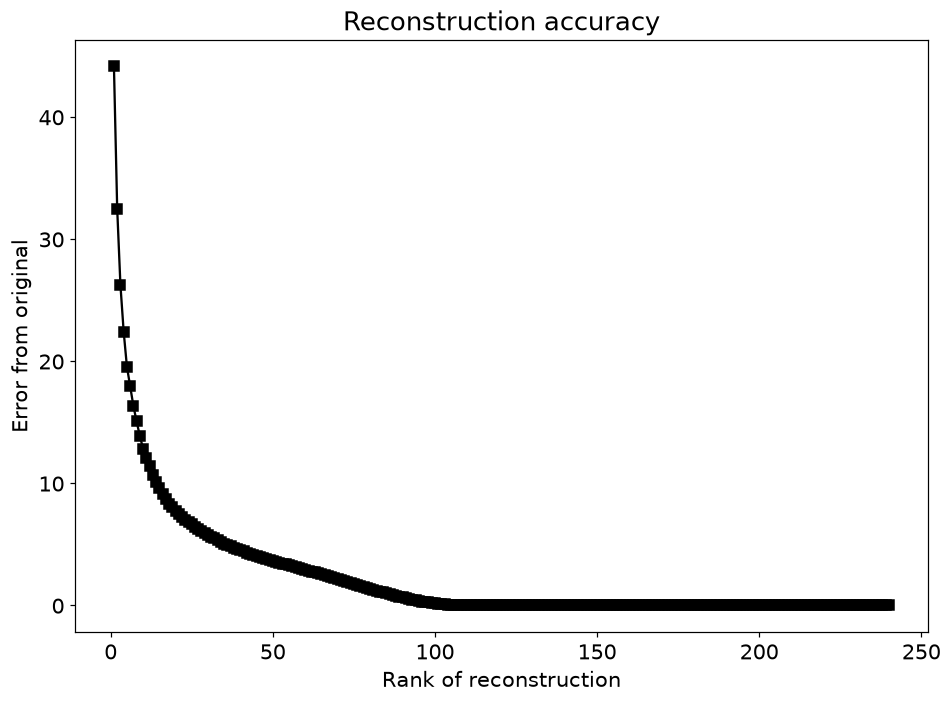

In [34]:
# range of components
k = range(1,len(s)+1)

# initialize variable to store results
kError = np.zeros(len(k))


# the loop
for i in range(len(k)):
  
  # reconstruction
  stravRec = U[:,:k[i]] @ S[:k[i],:k[i]] @ Vt[:k[i],:]

  # compute and store the error
  kError[i] = np.sqrt(np.sum((strav-stravRec)**2))



# show the results
plt.figure(figsize=(10,7))
plt.plot(k,kError,'ks-')
# plt.plot(k[:-1],np.diff(kError),'ks-') # uncomment to show derivative (and comment out the previous line)
plt.xlabel('Rank of reconstruction')
plt.ylabel('Error from original')
plt.title('Reconstruction accuracy')
plt.savefig(ASSET / 'Figure_14_11.png',dpi=140)
plt.show()

## 연습문제 13 · 주기적 잡음 추가

- **목표**: 구조적인 잡음이 SVD에서 어떻게 나타나는지 관찰합니다.
- **풀이 순서**: 회전한 사인파 이미지를 만들어 원본에 더한 후 범위를 0~1로 맞춥니다. 잡음 이미지의 SVD 층을 살펴봅니다.
- **결과 해석**: 주기적 무늬가 몇몇 성분에 강하게 나타날 수 있습니다. 특잇값이 크다는 이유만으로 유용한 신호라고 판단할 수 없습니다.

### 코드 14-34

- 원본: `original_py/LA4DS_ch14.py` 649–686행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

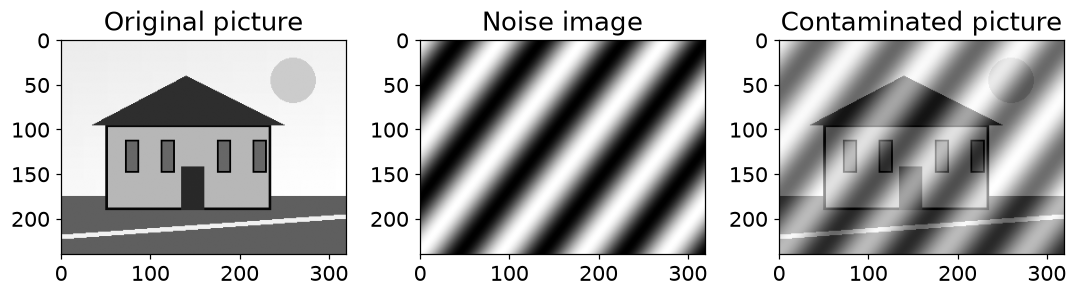

In [35]:
# create a spatial sine wave

# sine phases
sinefreq = .02   # arbitrary units
sinephas = np.pi/6 # rotate

# sine wave initializations
[x,y] = np.meshgrid(np.linspace(-100,100,strav.shape[1]),
                    np.linspace(-100,100,strav.shape[0]))
xp    = x*np.cos(sinephas) + y*np.sin(sinephas)


# compute sine wave
sinimg = np.sin( 2*np.pi*sinefreq*xp)

# scale to [0 1]
sinimg = (sinimg-np.min(sinimg)) / (np.max(sinimg)-np.min(sinimg))


# add to stravinsky picture and re-scale (using two lines)
stravNoise = strav + sinimg
stravNoise = stravNoise-np.min(stravNoise)
stravNoise = stravNoise/np.max(stravNoise)

# let's see it!
_,axs = plt.subplots(1,3,figsize=(10,7))
axs[0].imshow(strav,cmap='gray')
axs[0].set_title('Original picture')

axs[1].imshow(sinimg,cmap='gray')
axs[1].set_title('Noise image')

axs[2].imshow(stravNoise,cmap='gray')
axs[2].set_title('Contaminated picture')

plt.tight_layout()
plt.savefig(ASSET / 'Figure_14_12.png',dpi=140)
plt.show()

### 코드 14-35

- 원본: `original_py/LA4DS_ch14.py` 688–700행.
- **보완**: 입력 이미지와 일치하도록 표시 문구를 수정했습니다.

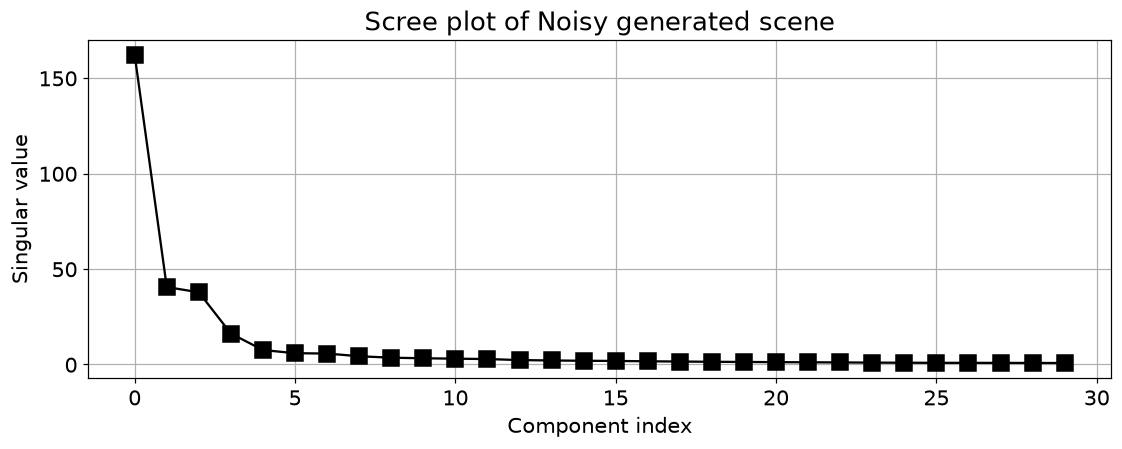

In [36]:
# SVD
Un,sn,Vtn = np.linalg.svd(stravNoise)
Sn = np.zeros_like(stravNoise)
np.fill_diagonal(Sn,sn)

# show scree plot
plt.figure(figsize=(12,4))
plt.plot(sn[:30],'ks-',markersize=10)
plt.xlabel('Component index')
plt.ylabel('Singular value')
plt.title('Scree plot of Noisy generated scene')
plt.grid()
plt.show()

### 코드 14-36

- 원본: `original_py/LA4DS_ch14.py` 702–745행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: 입력 이미지와 일치하도록 표시 문구를 수정했습니다.

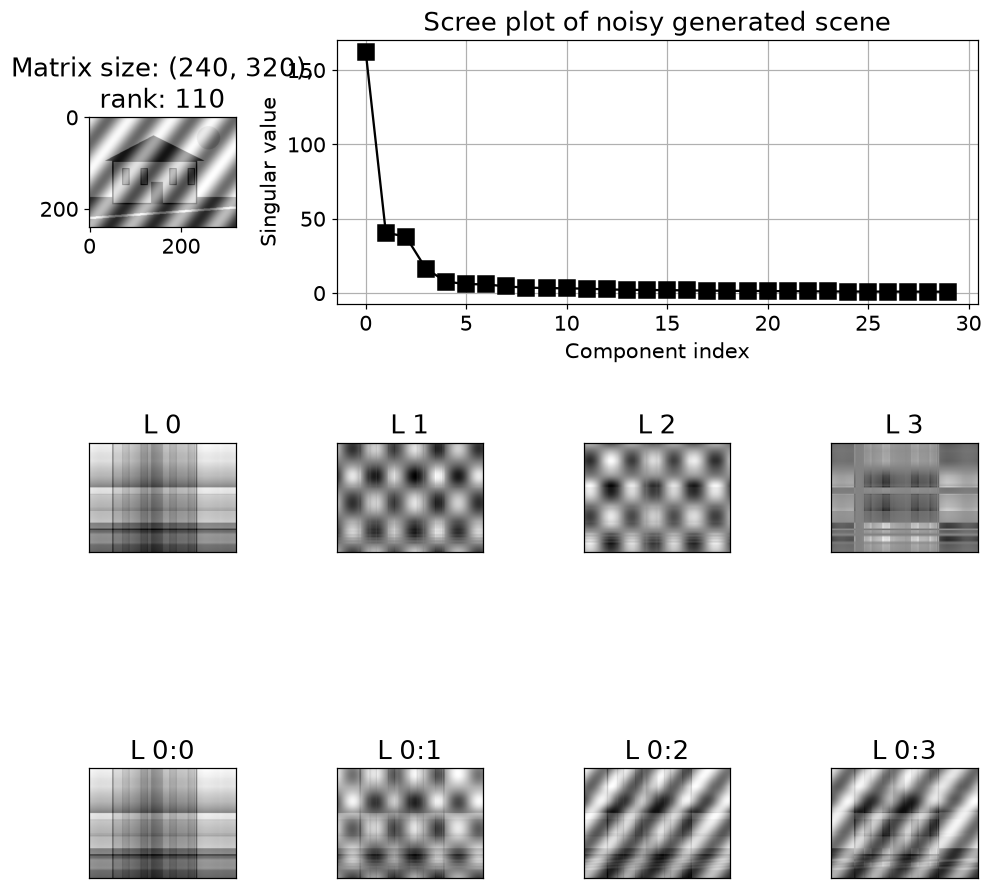

In [37]:
fig = plt.figure(figsize=(9,9))
gs = GridSpec(3,4,figure=fig)

# the image
ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(stravNoise,cmap='gray')
ax1.set_title(f'Matrix size: {strav.shape},\nrank: {np.linalg.matrix_rank(stravNoise)}')

# scree plot
ax2 = fig.add_subplot(gs[0,1:])
ax2.plot(sn[:30],'ks-',markersize=10)
ax2.set_xlabel('Component index')
ax2.set_ylabel('Singular value')
ax2.set_title('Scree plot of noisy generated scene')
ax2.grid()


## now show the first N "layers" separately
numLayers = 4
rank1mats = np.zeros((numLayers,strav.shape[0],strav.shape[1]))


# the loop
for i in range(numLayers):
    
    # create this layer
    rank1mats[i,:,:] = np.outer(Un[:,i],Vtn[i,:])*sn[i]
    
    # show this layer
    ax = fig.add_subplot(gs[1,i])
    ax.imshow(rank1mats[i,:,:],cmap='gray')
    ax.set_title(f'L {i}')
    ax.set_xticks([]), ax.set_yticks([])

    # show the cumulative sum of layers
    ax = fig.add_subplot(gs[2,i])
    ax.imshow(np.sum(rank1mats[:i+1,:,:],axis=0),cmap='gray')
    ax.set_title(f'L 0:{i}')
    ax.set_xticks([]), ax.set_yticks([])


plt.tight_layout()
plt.savefig(ASSET / 'Figure_14_13.png',dpi=140)
plt.show()

## 연습문제 14 · 선택 성분 제거

- **목표**: 성분을 제거할 때 잡음과 신호가 함께 사라질 수 있음을 확인합니다.
- **풀이 순서**: 원본의 인덱스 [1,2]를 잡음 후보로 선택하고 그 성분만 복원한 그림과 나머지 성분 그림을 비교합니다.
- **결과 해석**: 대체 이미지에서도 같은 인덱스가 순수 잡음이라는 보장은 없습니다. 제거 성분의 패턴과 원본 대비 오차를 함께 확인해야 하며 자동 잡음 제거 해법으로 일반화하지 않습니다.

### 코드 14-37

- 원본: `original_py/LA4DS_ch14.py` 749–785행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

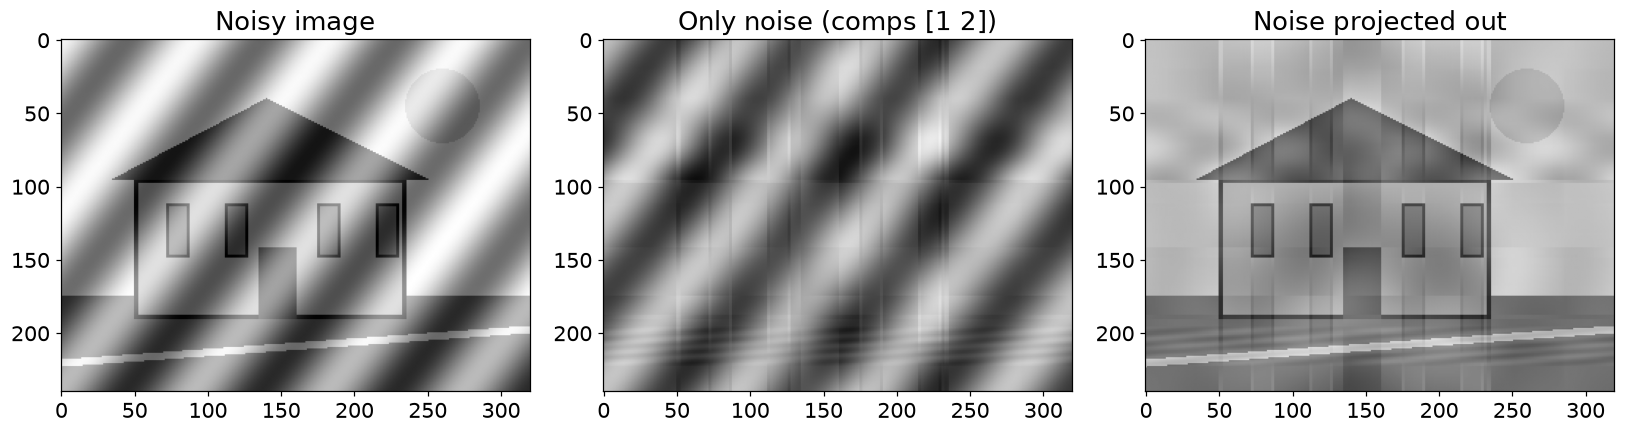

In [38]:
# Reconstruct based on first k layers

# noise components
noiseComps = np.array([1,2])

# reconstruction of the noise
stravRecNoise = Un[:,noiseComps] @ Sn[noiseComps,:][:,noiseComps] @ Vtn[noiseComps,:]


# reconstruction of the image with noise projected out
noNoiseCompsU = np.full(Un.shape[0],True)
noNoiseCompsU[noiseComps] = False

noNoiseCompsV = np.full(Vtn.shape[0],True)
noNoiseCompsV[noiseComps] = False

# here's the image without the noise components
stravRecNoNoise = Un[:,noNoiseCompsU] @ Sn[noNoiseCompsU,:][:,noNoiseCompsV] @ Vtn[noNoiseCompsV,:]




# show the original, reconstructed, and error
_,axs = plt.subplots(1,3,figsize=(15,6))

axs[0].imshow(stravNoise,cmap='gray')
axs[0].set_title('Noisy image')

axs[1].imshow(stravRecNoise,cmap='gray',vmin=-.5,vmax=.5)
axs[1].set_title(f'Only noise (comps {noiseComps})')

axs[2].imshow(stravRecNoNoise,cmap='gray',vmin=.1,vmax=.9)
axs[2].set_title('Noise projected out')

plt.tight_layout()
plt.savefig(ASSET / 'Figure_14_14.png',dpi=140)
plt.show()

### 코드 14-38

- 원본: `original_py/LA4DS_ch14.py` 787–788행.

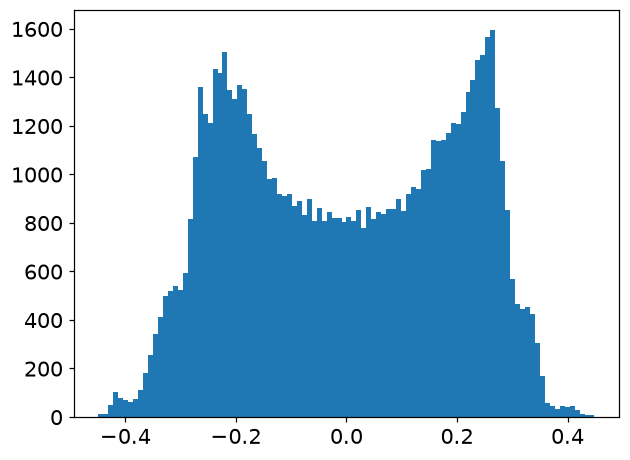

In [39]:
# histogram of noise reconstruction
plt.hist(stravRecNoise.flatten(),100);

## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [40]:
_X0=data.to_numpy(); _Xc=_X0-_X0.mean(axis=0)
_U,_s,_Vt=np.linalg.svd(_Xc,full_matrices=False)
_eig=np.linalg.eigvalsh(_Xc.T@_Xc/(len(_Xc)-1))[::-1]
print('PCA 고윳값과 SVD 환산값의 최대 차이:',np.max(np.abs(_eig-_s**2/(len(_Xc)-1))))
assert np.allclose(_eig,_s**2/(len(_Xc)-1))
_theory=np.sqrt(np.array([np.sum(s[j:]**2) for j in range(1,len(s)+1)]))
print('실제 이미지 복원 오차와 이론식 차이:',np.max(np.abs(kError-_theory)))
assert np.allclose(kError,_theory,atol=1e-9)
# 잡음 추가 단계와 같은 범위에서 원본 목표를 정의한다.
_sum=strav+sinimg
_target=(strav-_sum.min())/(_sum.max()-_sum.min())
print('잡음 포함/성분 제거 후 목표 대비 오차:',np.linalg.norm(stravNoise-_target),np.linalg.norm(stravRecNoNoise-_target))
print('성분 제거는 신호도 바꿀 수 있으므로 제거 그림을 함께 확인합니다.')


PCA 고윳값과 SVD 환산값의 최대 차이: 2.168404344971009e-19
실제 이미지 복원 오차와 이론식 차이: 5.894834633343764e-13
잡음 포함/성분 제거 후 목표 대비 오차: 96.3448124898372 79.85596480566757
성분 제거는 신호도 바꿀 수 있으므로 제거 그림을 함께 확인합니다.
